Gamma Pulses

In [2]:
import pandas as pd
import csv

file_path = "D:\\Programming_Essentials\\Nuclear_Project\\Neutron-Gamma-discrimination-Project\\Plastic Scintillator 1\\gamma pulses_1.csv"

parsed_data = []
header = []
with open(file_path, 'r') as f:
    csv_reader = csv.reader(f, delimiter=';')
 
    # Read the header
    header = next(csv_reader)
 
    # Read the data rows
    for row in csv_reader:
        if not row:
            continue

        # The first 6 columns are fixed, the rest are part of SAMPLES
        fixed_cols = row[:6]
        samples = row[6:]
 
        # Create a dictionary for the row, joining samples into a list
        parsed_row = {

            'BOARD': fixed_cols[0],

            'CHANNEL': fixed_cols[1],

            'TIMETAG': fixed_cols[2],

            'ENERGY': fixed_cols[3],

            'ENERGYSHORT': fixed_cols[4],

            'FLAGS': fixed_cols[5],

            'SAMPLES': samples

        }
        parsed_data.append(parsed_row)
 
# Create the DataFrame

df = pd.DataFrame(parsed_data)
print("First 5 rows of the DataFrame:")
print(df.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code...

# Expand SAMPLES into separate columns t0, t1, ...
samples_df_gamma = pd.DataFrame(df['SAMPLES'].tolist())
samples_df_gamma = samples_df_gamma.add_prefix('t')

# Concatenate the new columns with the original DataFrame (excluding the old SAMPLES column)
df_expanded_gamma = pd.concat([df.drop(columns=['BOARD', 'CHANNEL', 'TIMETAG', 'ENERGY', 'ENERGYSHORT', 'FLAGS', 'SAMPLES']), samples_df_gamma], axis=1)

# print("First 5 rows with expanded SAMPLES columns:")
# print(df_expanded.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code... 
df_expanded_gamma.head()



First 5 rows of the DataFrame:
| BOARD   | CHANNEL   | TIMETAG       | ENERGY   | ENERGYSHORT   | FLAGS   | SAMPLES                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t986,t987,t988,t989,t990,t991,t992,t993,t994,t995
0,936,936,936,936,936,936,936,936,936,936,...,936,936,936,936,936,936,936,936,936,936
1,936,936,936,936,936,936,936,936,936,936,...,932,936,936,936,936,936,936,936,936,936
2,936,936,936,936,936,936,936,936,936,936,...,936,936,936,936,936,936,936,936,936,936
3,936,936,936,936,936,936,936,936,936,936,...,936,936,936,936,936,936,936,936,936,936
4,936,936,936,936,940,936,936,936,936,936,...,936,936,936,936,936,936,936,936,936,936


In [ ]:

# Ensure numeric (important)
df_expanded_gamma = df_expanded_gamma.apply(pd.to_numeric, errors='coerce')

# Subtract max from each t-value
df_expanded_gamma = df_expanded_gamma.sub(df_expanded_gamma.max(axis=1), axis=0).abs()
df_expanded_gamma['t_mean'] = df_expanded_gamma.mean(axis=1)
df_expanded_gamma.head()

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t987,t988,t989,t990,t991,t992,t993,t994,t995,t_mean
0,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,14.706827
1,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,14.522088
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.662651
3,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,10.598394
4,4,4,4,4,0,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,15.357430


In [ ]:
#average value
mean_waveform_1 = df_expanded_gamma.mean(axis=0).iloc[:-1]
mean_waveform_1

t0      2.080548
t1      2.080784
t2      2.082320
t3      2.080784
t4      2.080548
          ...   
t991    2.183536
t992    2.185308
t993    2.187670
t994    2.177867
t995    2.178694
Length: 996, dtype: float64

996


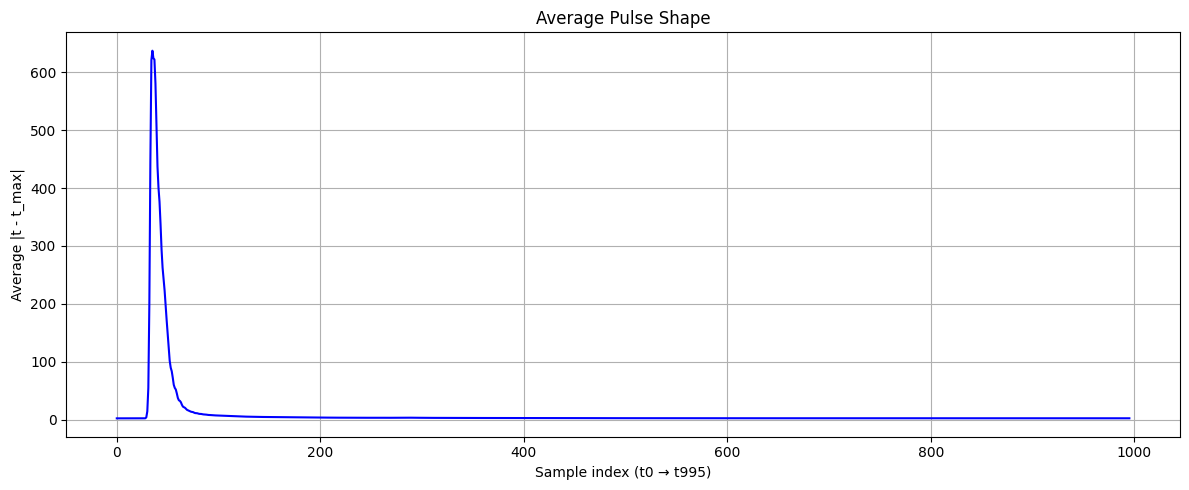

In [ ]:
import matplotlib.pyplot as plt

# Compute column-wise mean
mean_waveform_gamma = df_expanded_gamma.mean(axis=0).iloc[:-1]
print(len(mean_waveform_gamma))
# Plot
plt.figure(figsize=(12, 5))
plt.plot(range(len(mean_waveform_gamma)), mean_waveform_gamma, color='blue', linewidth=1.5)
plt.xlabel("Sample index (t0 → t995)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import csv

# List of file paths
file_paths = [
    "C:/Users/jayan/Downloads/21_08_25/21_08_25/Plastic Scintillator 1/neutron pulses_1.csv",
    "C:/Users/jayan/Downloads/21_08_25/21_08_25/Plastic Scintillator 1/neutron pulses_2.csv",
    "C:/Users/jayan/Downloads/21_08_25/21_08_25/Plastic Scintillator 1/neutron pulses_3.csv"
]

parsed_data = []

# Loop through all files
for file_path in file_paths:
    with open(file_path, 'r') as f:
        csv_reader = csv.reader(f, delimiter=';')

        # Read header (skip, assuming all files have same header)
        header = next(csv_reader)

        # Read data rows
        for row in csv_reader:
            if not row:
                continue

            # First 6 columns fixed, rest are SAMPLES
            fixed_cols = row[:6]
            samples = row[6:]

            parsed_row = {
                'BOARD': fixed_cols[0],
                'CHANNEL': fixed_cols[1],
                'TIMETAG': fixed_cols[2],
                'ENERGY': fixed_cols[3],
                'ENERGYSHORT': fixed_cols[4],
                'FLAGS': fixed_cols[5],
                'SAMPLES': samples
            }
            parsed_data.append(parsed_row)

# Create initial DataFrame
df_neutron = pd.DataFrame(parsed_data)

print("First 5 rows of the DataFrame:")
print(df_neutron.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code...

# Expand SAMPLES into separate columns t0, t1, ...
samples_df_neutron = pd.DataFrame(df_neutron['SAMPLES'].tolist())
samples_df_neutron = samples_df_neutron.add_prefix('t')

# Concatenate the new columns with the original DataFrame (excluding the old SAMPLES column)
df_expanded_neutron = pd.concat([df_neutron.drop(columns=['BOARD','CHANNEL','TIMETAG','ENERGY','ENERGYSHORT','FLAGS','SAMPLES']), samples_df_neutron], axis=1)

# print("First 5 rows with expanded SAMPLES columns:")
# print(df_expanded.head().to_markdown(index=False, numalign="left", stralign="left"))
# ...existing code... 
df_expanded_neutron.head()



First 5 rows of the DataFrame:
| BOARD   | CHANNEL   | TIMETAG        | ENERGY   | ENERGYSHORT   | FLAGS   | SAMPLES                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t986,t987,t988,t989,t990,t991,t992,t993,t994,t995
0,936,936,936,936,936,936,936,936,936,936,...,936,936,940,936,936,936,936,936,936,936
1,936,936,936,936,936,936,936,936,936,936,...,936,936,936,936,936,936,936,936,936,936
2,936,936,936,936,936,936,936,936,936,936,...,936,936,936,936,936,936,936,936,936,936
3,936,936,936,936,936,936,936,936,936,936,...,936,936,936,936,936,936,936,936,936,936
4,936,936,936,936,936,936,936,936,936,936,...,936,936,936,936,936,932,932,936,936,936


In [ ]:

# Ensure numeric (important)
df_expanded_neutron = df_expanded_neutron.apply(pd.to_numeric, errors='coerce')

# Subtract max from each t-value
df_expanded_neutron = df_expanded_neutron.sub(df_expanded_neutron.max(axis=1), axis=0).abs()
df_expanded_neutron['t_mean'] = df_expanded_neutron.mean(axis=1)
df_expanded_neutron.head()


,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t987,t988,t989,t990,t991,t992,t993,t994,t995,t_mean
0,4,4,4,4,4,4,4,4,4,4,...,4,0,4,4,4,4,4,4,4,12.076305
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.236948
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.449799
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.678715
4,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,8,8,4,4,4,13.967871


In [ ]:
mean_waveform_2 = df_expanded_neutron.mean(axis=0).iloc[:-1]
mean_waveform_2

t0      2.142026
t1      2.138200
t2      2.142639
t3      2.142179
t4      2.140037
          ...   
t991    2.528007
t992    2.524181
t993    2.521732
t994    2.529997
t995    2.522192
Length: 996, dtype: float64

996


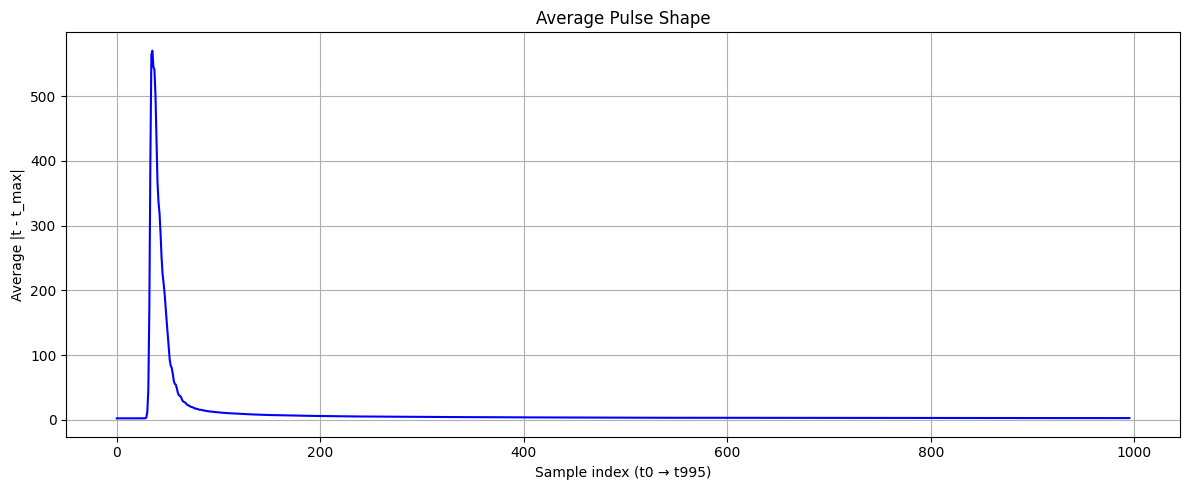

In [ ]:
import matplotlib.pyplot as plt


# Compute column-wise mean
mean_waveform_neutron = df_expanded_neutron.mean(axis=0).iloc[:-1]
print(len(mean_waveform_neutron))
# Plot
plt.figure(figsize=(12, 5))
plt.plot(range(len(mean_waveform_neutron)), mean_waveform_neutron, color='blue', linewidth=1.5)
plt.xlabel("Sample index (t0 → t995)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape")
plt.grid(True)
plt.tight_layout()
plt.show()


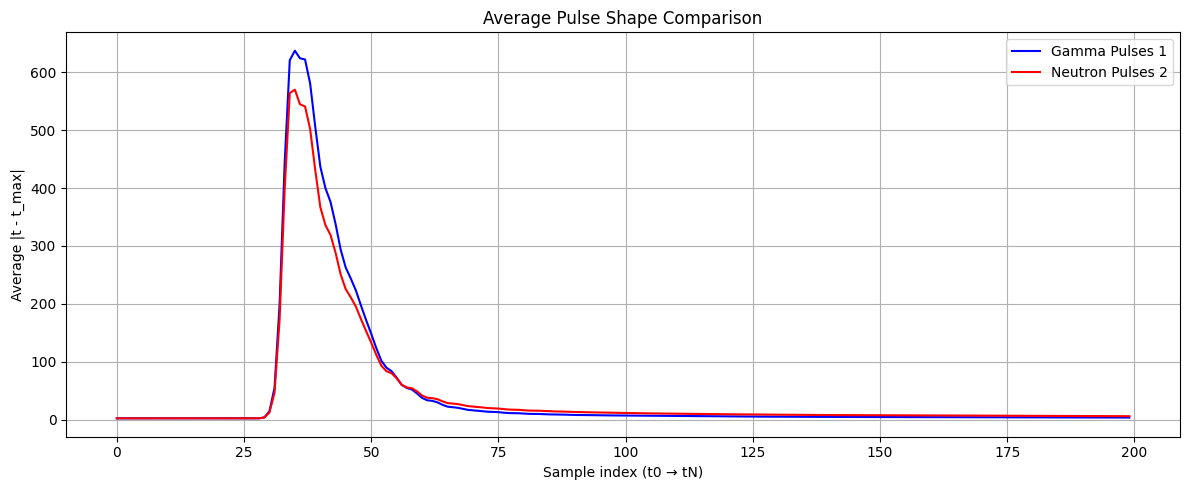

In [ ]:
import matplotlib.pyplot as plt

t_cols_1 = df_expanded_gamma.filter(regex=r'^t').columns[:-1]
t_cols_2 = df_expanded_neutron.filter(regex=r'^t').columns[:-1]

# Compute column-wise mean (drop last column if needed) Averaged
mean_waveform_gamma = df_expanded_gamma.mean(axis=0).iloc[:-1]
mean_waveform_neutron = df_expanded_neutron.mean(axis=0).iloc[:-1]

# For Normalization
mean_waveform_gamma_norm = (mean_waveform_gamma -mean_waveform_gamma.min()) / (mean_waveform_gamma.max() - mean_waveform_gamma.min())
mean_waveform_neutron_norm = (mean_waveform_neutron -mean_waveform_neutron.min()) / (mean_waveform_neutron.max() - mean_waveform_neutron.min())

df_gamma_norm = df_expanded_gamma[t_cols_1].sub(
    df_expanded_gamma[t_cols_1].min(axis=1), axis=0
).div(
    df_expanded_gamma[t_cols_1].max(axis=1) - df_expanded_gamma[t_cols_1].min(axis=1),
    axis=0
)

df_neutron_norm = df_expanded_neutron[t_cols_2].sub(
    df_expanded_neutron[t_cols_2].min(axis=1), axis=0
).div(
    df_expanded_neutron[t_cols_2].max(axis=1) - df_expanded_neutron[t_cols_2].min(axis=1),
    axis=0
)

# Plot both on same figure
x = range(200)

plt.figure(figsize=(12, 5))
plt.plot(x, mean_waveform_gamma[0:200], color='blue', linewidth=1.5, label='Gamma Pulses 1')
plt.plot(x, mean_waveform_neutron[0:200], color='red', linewidth=1.5, label='Neutron Pulses 2')

plt.xlabel("Sample index (t0 → tN)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#plt.savefig("C:/Users/jayan/Downloads/21_08_25/21_08_25/Plots_Avg_n_Normalized/Averaged plots.png", dpi=300)  # Save as PNG with high resolution



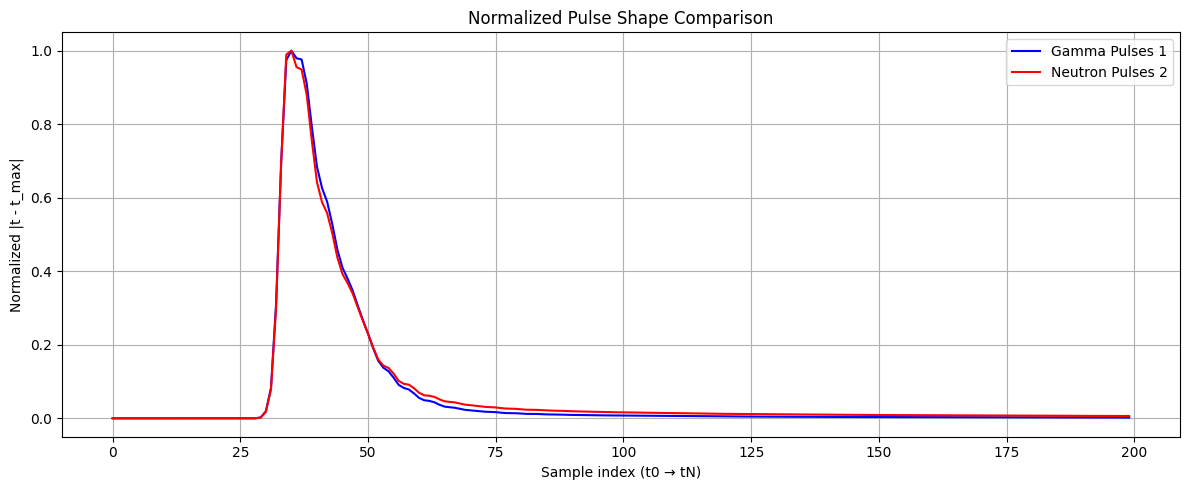

In [ ]:
# normalized
x = range(200)
plt.figure(figsize=(12, 5))
plt.plot(x, mean_waveform_gamma_norm[0:200], color='blue', linewidth=1.5, label='Gamma Pulses 1')
plt.plot(x, mean_waveform_neutron_norm[0:200], color='red', linewidth=1.5, label='Neutron Pulses 2')

plt.xlabel("Sample index (t0 → tN)")
plt.ylabel("Normalized |t - t_max|")
plt.title("Normalized Pulse Shape Comparison")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
#plt.savefig("C:/Users/jayan/Downloads/21_08_25/21_08_25/Plots_Avg_n_Normalized/Normalized plots.png", dpi=300)  # Save as PNG with high resolution


Charge Comparison Method

-0.6595911949685536
-0.6348484848484853
Split @ 50: Accuracy = 0.9043
Confusion Matrix:
 [[6302  472]
 [ 677 4550]]
-0.7932389937106918
-0.7681818181818184
Split @ 55: Accuracy = 0.9303
Confusion Matrix:
 [[6446  328]
 [ 508 4719]]
-0.8592767295597487
-0.8333333333333334
Split @ 60: Accuracy = 0.9277
Confusion Matrix:
 [[6441  333]
 [ 535 4692]]
-0.897798742138365
-0.8696969696969696
Split @ 65: Accuracy = 0.9178
Confusion Matrix:
 [[6421  353]
 [ 633 4594]]
-0.919811320754717
-0.8893939393939395
Split @ 70: Accuracy = 0.9053
Confusion Matrix:
 [[6365  409]
 [ 728 4499]]
-0.9410377358490566
-0.9136363636363637
Split @ 75: Accuracy = 0.8909
Confusion Matrix:
 [[6311  463]
 [ 846 4381]]
-0.9559748427672957
-0.9318181818181818
Split @ 80: Accuracy = 0.8757
Confusion Matrix:
 [[6253  521]
 [ 971 4256]]
-0.9654088050314464
-0.9499999999999998
Split @ 85: Accuracy = 0.8633
Confusion Matrix:
 [[6246  528]
 [1112 4115]]


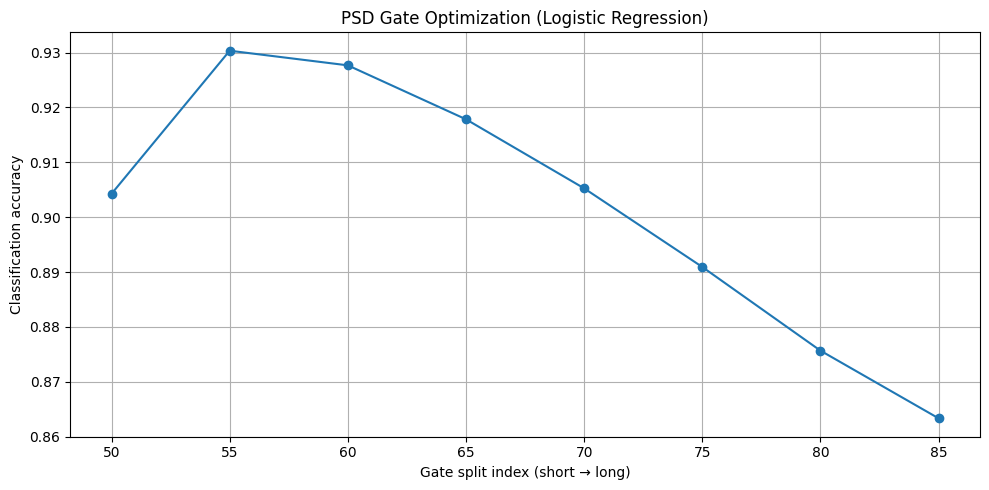

In [ ]:
# Logistic Reg --------------------------------
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report, confusion_matrix
# #calculation of ratios
# #1 Gamma
# gamma_short_tail = df_1_norm.iloc[:, 25:55].sum(axis=1)
# gamma_long_tail  = df_1_norm.iloc[:, 55:105].sum(axis=1)
# gamma_ratio = gamma_short_tail / gamma_long_tail

# #2 Neutron
# neutron_short_tail = df_2_norm.iloc[:, 25:55].sum(axis=1)
# neutron_long_tail  = df_2_norm.iloc[:, 55:105].sum(axis=1)
# neutron_ratio = neutron_short_tail / neutron_long_tail

# print(gamma_ratio)
# print(neutron_ratio)
# # 3. Prepare data and labels
# X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
# y = np.concatenate([np.zeros_like(gamma_ratio), np.ones_like(neutron_ratio)])  # 0: gamma, 1: neutron

# # 4. Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # 5. Logistic Regression
# clf = LogisticRegression()
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)

# # 6. Evaluation
# print("Classification Report:\n", classification_report(y_test, y_pred, target_names=['gamma', 'neutron']))
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------
# Gate sweep parameters
# -------------------------------
short_start = 25
long_end = 105
splits = range(50, 86, 5)   # 50, 55, 60, ..., 100

accuracies = []

# -------------------------------
# Loop over split positions
# -------------------------------
for split in splits:
    # ---- Gamma ratios ----
    gamma_short = df_gamma_norm.iloc[:, short_start:split].sum(axis=1)
    gamma_long  = df_gamma_norm.iloc[:, split:long_end].sum(axis=1)
    gamma_ratio = (gamma_long - gamma_short) / (gamma_long + gamma_short)
    print(gamma_ratio[1])
    # ---- Neutron ratios ----
    neutron_short = df_neutron_norm.iloc[:, short_start:split].sum(axis=1)
    neutron_long  = df_neutron_norm.iloc[:, split:long_end].sum(axis=1)
    neutron_ratio = (neutron_long - neutron_short) / (neutron_long + neutron_short)
    print(neutron_ratio[1])

    # ---- Dataset ----
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([
        np.zeros(len(gamma_ratio)),   # gamma = 0
        np.ones(len(neutron_ratio))   # neutron = 1
    ])

    # ---- Train / test split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # ---- Logistic Regression ----
    clf = LogisticRegression()
    clf.fit(X_train, y_train)

    # ---- Accuracy ----
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Split @ {split}: Accuracy = {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# -------------------------------
# Plot accuracy vs gate split
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(splits, accuracies, marker='o')
plt.xlabel("Gate split index (short → long)")
plt.ylabel("Classification accuracy")
plt.title("PSD Gate Optimization (Logistic Regression)")
plt.grid(True)
plt.tight_layout()
plt.show()



Charge Weighted comparison Method

12.760776882993841
14.328081556997214
Split @ 50: Accuracy = 0.9188
Confusion Matrix:
 [[6357  417]
 [ 557 4670]]
7.953967558088556
9.362467866323902
Split @ 55: Accuracy = 0.9309
Confusion Matrix:
 [[6412  362]
 [ 467 4760]]
5.656659619450316
7.006611570247935
Split @ 60: Accuracy = 0.9263
Confusion Matrix:
 [[6382  392]
 [ 493 4734]]
4.2883181441590725
5.665316045380877
Split @ 65: Accuracy = 0.9159
Confusion Matrix:
 [[6347  427]
 [ 582 4645]]
3.472153972153973
4.906976744186048
Split @ 70: Accuracy = 0.9045
Confusion Matrix:
 [[6277  497]
 [ 649 4578]]
2.6480356419603086
3.9334916864608083
Split @ 75: Accuracy = 0.8908
Confusion Matrix:
 [[6212  562]
 [ 748 4479]]
2.038987138263666
3.171764705882354
Split @ 80: Accuracy = 0.8759
Confusion Matrix:
 [[6125  649]
 [ 840 4387]]
1.6376000000000004
2.3752913752913765
Split @ 85: Accuracy = 0.8615
Confusion Matrix:
 [[6056  718]
 [ 944 4283]]


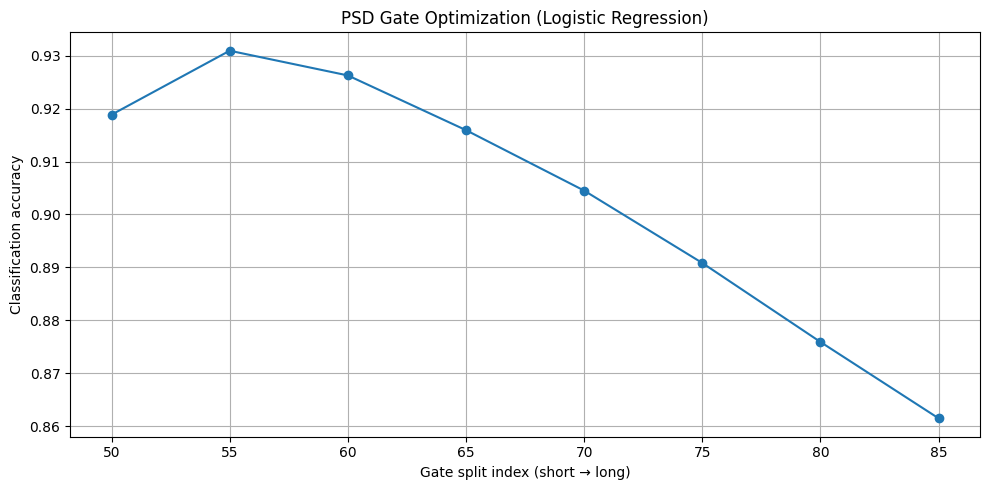

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

# -------------------------------
# Gate sweep parameters
# -------------------------------
short_start = 25
long_end = 105
splits = range(50, 86, 5)   # 50, 55, 60, ..., 100

accuracies = []

# -------------------------------
# Loop over split positions
# -------------------------------
for split in splits:
    # Short and long gates
    gamma_short = df_gamma_norm.iloc[:, short_start:split].sum(axis=1)

    # Weighted sum for long gate
    long_indices = np.arange(split, long_end)  # j = split, split+1, ...
    gamma_long_values = df_gamma_norm.iloc[:, split:long_end].values
    weights = long_indices  # simple linear weight j, you can modify
    weighted_long = (gamma_long_values * weights).sum(axis=1)

    # Weighted ratio
    gamma_ratio = weighted_long / (gamma_short)

    print(gamma_ratio[1])
    # ---- Neutron ratios ----
    neutron_short = df_neutron_norm.iloc[:, short_start:split].sum(axis=1)
    neutron_long_values = df_neutron_norm.iloc[:, split:long_end].values
    weighted_long_neutron = (neutron_long_values * weights).sum(axis=1)
    neutron_ratio = weighted_long_neutron / (neutron_short)
    print(neutron_ratio[1])

    # ---- Dataset ----
    X = np.concatenate([gamma_ratio, neutron_ratio]).reshape(-1, 1)
    y = np.concatenate([
        np.zeros(len(gamma_ratio)),   # gamma = 0
        np.ones(len(neutron_ratio))   # neutron = 1
    ])

    # ---- Train / test split ----
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    # ---- Logistic Regression ----
    clf = LogisticRegression()
    clf.fit(X_train, y_train)

    # ---- Accuracy ----
    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Split @ {split}: Accuracy = {acc:.4f}")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
# -------------------------------
# Plot accuracy vs gate split
# -------------------------------
plt.figure(figsize=(10, 5))
plt.plot(splits, accuracies, marker='o')
plt.xlabel("Gate split index (short → long)")
plt.ylabel("Classification accuracy")
plt.title("PSD Gate Optimization (Logistic Regression)")
plt.grid(True)
plt.tight_layout()
plt.show()



Time domain

In [ ]:
# Select t0 through t995 columns
t_cols = [f't{i}' for i in range(996)]

# Get the subset DataFrame
t_data = df_expanded_neutron[t_cols]

# Get maximum value per row
max_values = t_data.max(axis=1)

# Get column name where maximum occurs
max_columns = t_data.idxmax(axis=1)

# Create a DataFrame with both
max_info = pd.DataFrame({
    'max_value_t0_t995': max_values,
    'max_column_t0_t995': max_columns
})

print("Maximum values and their columns (first 10 rows):")
print(max_info.head(10))

Maximum values and their columns (first 10 rows):
   max_value_t0_t995 max_column_t0_t995
0                520                t35
1                420                t34
2                576                t35
3                480                t35
4                676                t35
5                552                t35
6                544                t34
7                676                t34
8                652                t35
9                768                t35


32 start_idx
46 end_idx
33 start_idx
47 end_idx
32 start_idx
46 end_idx
32 start_idx
48 end_idx
33 start_idx
49 end_idx
33 start_idx
46 end_idx
32 start_idx
46 end_idx
32 start_idx
46 end_idx
33 start_idx
45 end_idx
32 start_idx
45 end_idx
32 start_idx
48 end_idx
32 start_idx
46 end_idx
33 start_idx
45 end_idx
33 start_idx
46 end_idx
32 start_idx
46 end_idx
33 start_idx
47 end_idx
33 start_idx
46 end_idx
33 start_idx
47 end_idx
33 start_idx
45 end_idx
33 start_idx
46 end_idx
33 start_idx
47 end_idx
33 start_idx
47 end_idx
33 start_idx
48 end_idx
32 start_idx
48 end_idx
33 start_idx
47 end_idx
32 start_idx
45 end_idx
32 start_idx
46 end_idx
32 start_idx
46 end_idx
33 start_idx
48 end_idx
32 start_idx
44 end_idx
33 start_idx
47 end_idx
32 start_idx
47 end_idx
33 start_idx
47 end_idx
33 start_idx
49 end_idx
32 start_idx
44 end_idx
33 start_idx
47 end_idx
33 start_idx
47 end_idx
33 start_idx
45 end_idx
32 start_idx
47 end_idx
32 start_idx
45 end_idx
33 start_idx
46 end_idx
33 start_idx
46 

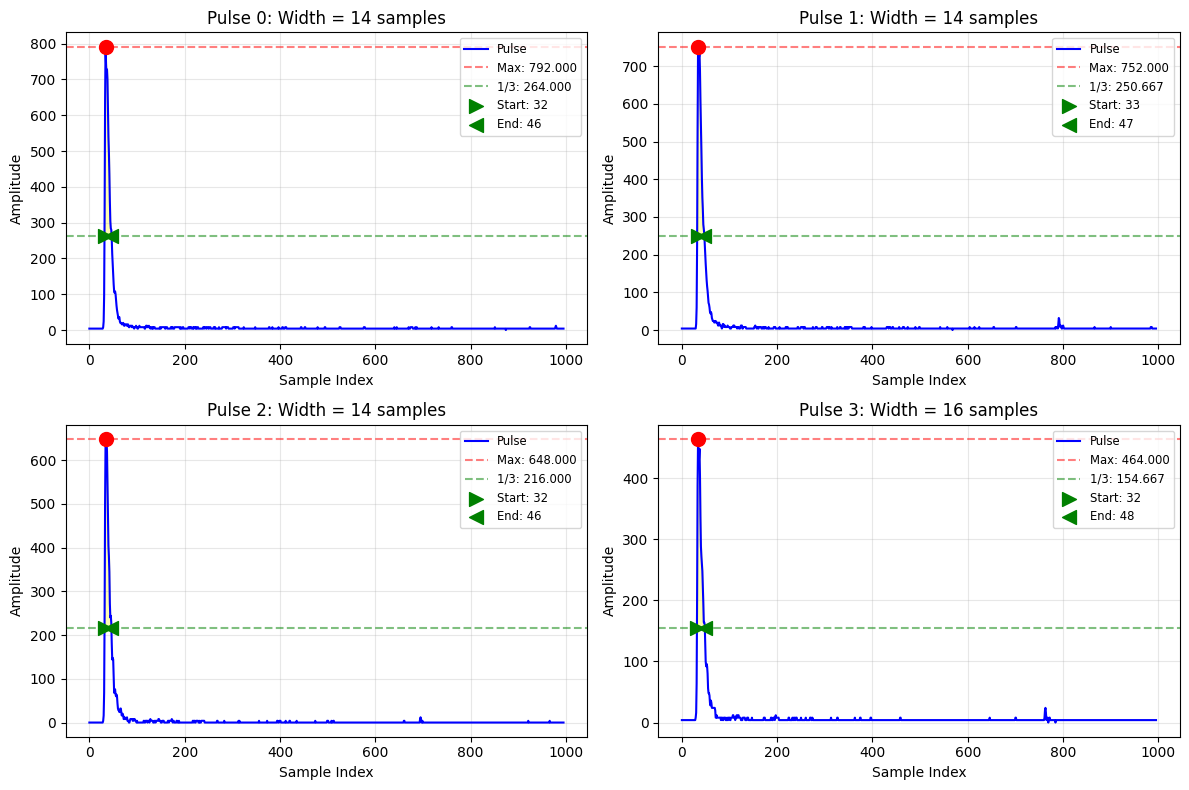


Added new columns to df_expanded_gamma:
Columns added: ['max_value', 'max_column', 'threshold_1_3', 'start_idx_1_3', 'end_idx_1_3', 'width_at_1_3']


In [ ]:
# Select t0 through t995 columns
t_cols = [f't{i}' for i in range(996)]

# Get the subset DataFrame
t_data = df_expanded_gamma[t_cols]

# Get maximum value per row
max_values = t_data.max(axis=1)

# Get column name where maximum occurs
max_columns = t_data.idxmax(axis=1)

# Calculate 1/3 of maximum value for each row
threshold_values = max_values / 3

# Function to find crossing points at threshold
def find_threshold_crossings(row_values, threshold):
    """Find indices where signal crosses the threshold value"""
    above_threshold = row_values > threshold
    
    start_idx = None
    

    end_idx = None
    

    for i, val in enumerate(above_threshold):
        if val and start_idx is None:
            start_idx = i  # First time above threshold
        elif not val and start_idx is not None:
            end_idx = i - 1  # End of the first above-threshold segment
            break
    
    # If waveform stays above threshold until the end
    if start_idx is not None and end_idx is None:
        end_idx = len(row_values) - 1
    
    if start_idx is None:
        return None, None, None
    
    width = end_idx - start_idx
    print(start_idx,"start_idx")
    print(end_idx,"end_idx")
    return start_idx, end_idx, width

# Find crossings for each row
start_indices = []
end_indices = []
widths = []

for idx, row in t_data.iterrows():
    start, end, width = find_threshold_crossings(row.values, threshold_values.iloc[idx])
    start_indices.append(start)
    end_indices.append(end)
    widths.append(width)

# Create a DataFrame with all information
max_info = pd.DataFrame({
    'max_value_t0_t995': max_values,
    'max_column_t0_t995': max_columns,
    'threshold_1_3': threshold_values,
    'start_idx_1_3': start_indices,
    'end_idx_1_3': end_indices,
    'width_at_1_3': widths
})

# Convert column name to numeric index
max_info['max_index_numeric'] = max_info['max_column_t0_t995'].str.replace('t', '').astype(int)

print("Maximum values and 1/3 threshold analysis (first 10 rows):")
print(max_info.head(10))

# Statistics summary
print("\n" + "="*70)
print("1/3 THRESHOLD ANALYSIS SUMMARY")
print("="*70)
print(f"Total pulses analyzed: {len(t_data)}")

# Count pulses that reach the threshold
valid_pulses = max_info['width_at_1_3'].notna()
num_valid = valid_pulses.sum()
print(f"Pulses that reach 1/3 threshold: {num_valid} ({num_valid/len(t_data)*100:.1f}%)")

if num_valid > 0:
    valid_widths = max_info.loc[valid_pulses, 'width_at_1_3']
    print(f"\nWidth at 1/3 of maximum:")
    print(f"  Mean width: {valid_widths.mean():.2f} samples")
    print(f"  Std deviation: {valid_widths.std():.2f} samples")
    print(f"  Minimum width: {valid_widths.min():.2f} samples")
    print(f"  Maximum width: {valid_widths.max():.2f} samples")
    print(f"  Median width: {valid_widths.median():.2f} samples")

print(f"\nThreshold values (1/3 of max):")
print(f"  Mean: {threshold_values.mean():.6f}")
print(f"  Range: {threshold_values.min():.6f} to {threshold_values.max():.6f}")

# Ratio check
print(f"\nRatio analysis:")
actual_ratio = (threshold_values / max_values).mean()
print(f"  Actual mean (threshold/max): {actual_ratio:.6f}")
print(f"  Expected: 0.333333")
print(f"  Difference: {abs(actual_ratio - 1/3):.6f}")
print("="*70)

# Optional: Visualization of a few example pulses
import matplotlib.pyplot as plt

# Plot first 4 pulses as examples
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i in range(min(4, len(t_data))):
    # Get pulse data
    pulse_data = t_data.iloc[i].values
    max_val = max_values.iloc[i]
    threshold = threshold_values.iloc[i]
    max_col = max_columns.iloc[i]
    max_idx = int(max_col.replace('t', ''))
    start_idx = start_indices[i]
    end_idx = end_indices[i]
    width = widths[i]
    
    # Plot
    axes[i].plot(range(996), pulse_data, 'b-', linewidth=1.5, label='Pulse')
    axes[i].axhline(y=max_val, color='r', linestyle='--', alpha=0.5, label=f'Max: {max_val:.3f}')
    axes[i].axhline(y=threshold, color='g', linestyle='--', alpha=0.5, label=f'1/3: {threshold:.3f}')
    
    # Mark maximum point
    axes[i].scatter(max_idx, max_val, color='red', s=100, zorder=5)
    
    # Mark crossing points if they exist
    if start_idx is not None and end_idx is not None:
        axes[i].scatter(start_idx, threshold, color='green', s=100, marker='>', zorder=5, label=f'Start: {start_idx}')
        axes[i].scatter(end_idx, threshold, color='green', s=100, marker='<', zorder=5, label=f'End: {end_idx}')
        
        # Fill area above threshold
        axes[i].fill_between(range(996), pulse_data, threshold, 
                           where=(pulse_data > threshold), 
                           color='yellow', alpha=0.3)
        
        title = f'Pulse {i}: Width = {width} samples'
    else:
        title = f'Pulse {i}: Below threshold'
    
    axes[i].set_title(title)
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Add the information back to original DataFrame if needed
df_expanded_gamma['max_value'] = max_values
df_expanded_gamma['max_column'] = max_columns
df_expanded_gamma['threshold_1_3'] = threshold_values
df_expanded_gamma['start_idx_1_3'] = start_indices
df_expanded_gamma['end_idx_1_3'] = end_indices
df_expanded_gamma['width_at_1_3'] = widths

print("\nAdded new columns to df_expanded_gamma:")
new_cols = ['max_value', 'max_column', 'threshold_1_3', 'start_idx_1_3', 'end_idx_1_3', 'width_at_1_3']
print(f"Columns added: {new_cols}")

31 start_idx
56 end_idx
32 start_idx
55 end_idx
31 start_idx
54 end_idx
31 start_idx
57 end_idx
32 start_idx
56 end_idx
32 start_idx
57 end_idx
31 start_idx
53 end_idx
31 start_idx
51 end_idx
32 start_idx
53 end_idx
31 start_idx
54 end_idx
31 start_idx
55 end_idx
32 start_idx
54 end_idx
32 start_idx
54 end_idx
32 start_idx
54 end_idx
31 start_idx
56 end_idx
32 start_idx
56 end_idx
32 start_idx
56 end_idx
32 start_idx
54 end_idx
32 start_idx
55 end_idx
32 start_idx
56 end_idx
32 start_idx
56 end_idx
32 start_idx
55 end_idx
32 start_idx
57 end_idx
31 start_idx
55 end_idx
32 start_idx
56 end_idx
31 start_idx
54 end_idx
32 start_idx
54 end_idx
31 start_idx
53 end_idx
32 start_idx
56 end_idx
31 start_idx
51 end_idx
32 start_idx
56 end_idx
31 start_idx
57 end_idx
32 start_idx
55 end_idx
32 start_idx
57 end_idx
31 start_idx
57 end_idx
32 start_idx
55 end_idx
32 start_idx
55 end_idx
32 start_idx
54 end_idx
31 start_idx
56 end_idx
31 start_idx
55 end_idx
32 start_idx
55 end_idx
32 start_idx
55 

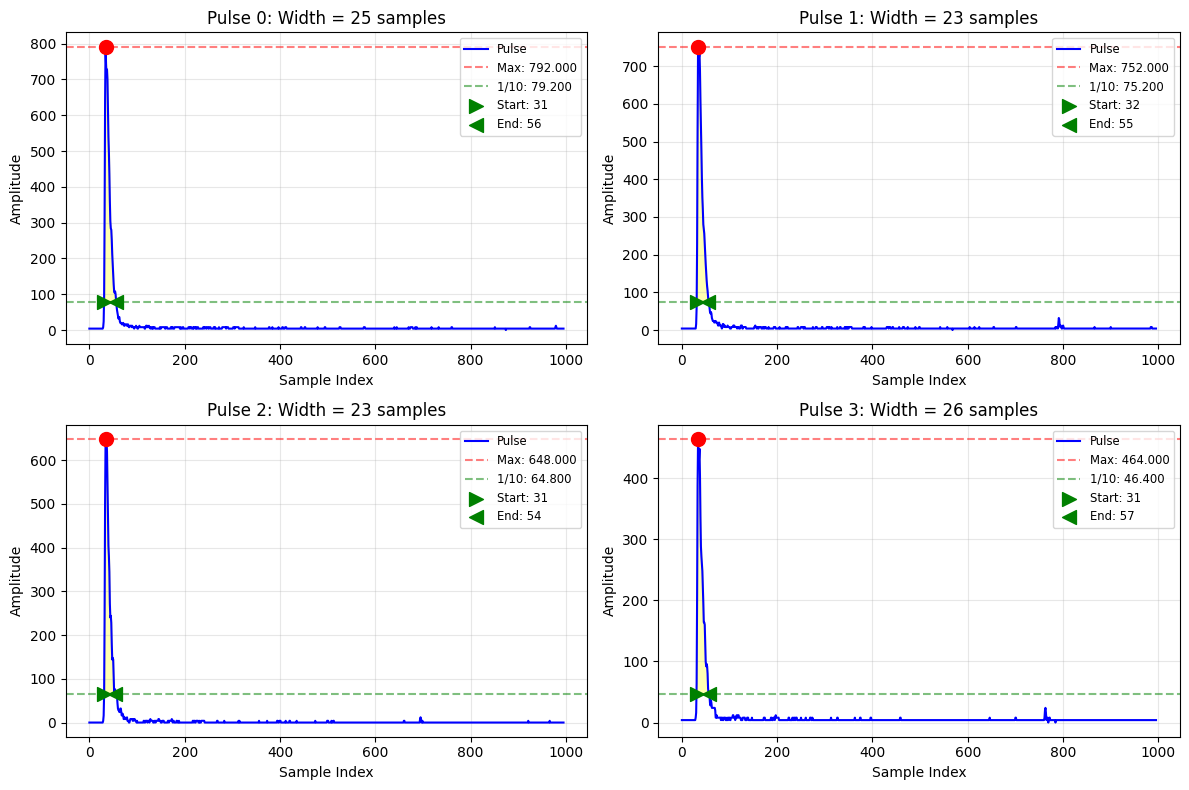


Added new columns to df_expanded_gamma:
Columns added: ['max_value', 'max_column', 'threshold_1_10', 'start_idx_1_10', 'end_idx_1_10', 'width_at_1_10']


In [ ]:
# Select t0 through t995 columns
t_cols = [f't{i}' for i in range(996)]

# Get the subset DataFrame
t_data = df_expanded_gamma[t_cols]

# Get maximum value per row
max_values = t_data.max(axis=1)

# Get column name where maximum occurs
max_columns = t_data.idxmax(axis=1)

# Calculate 1/3 of maximum value for each row
threshold_values = max_values / 10

# Function to find crossing points at threshold
def find_threshold_crossings(row_values, threshold):
    """Find indices where signal crosses the threshold value"""
    above_threshold = row_values > threshold
    
    start_idx = None
    

    end_idx = None
    

    for i, val in enumerate(above_threshold):
        if val and start_idx is None:
            start_idx = i  # First time above threshold
        elif not val and start_idx is not None:
            end_idx = i - 1  # End of the first above-threshold segment
            break
    
    # If waveform stays above threshold until the end
    if start_idx is not None and end_idx is None:
        end_idx = len(row_values) - 1
    
    if start_idx is None:
        return None, None, None
    
    width = end_idx - start_idx
    print(start_idx,"start_idx")
    print(end_idx,"end_idx")
    return start_idx, end_idx, width

# Find crossings for each row
start_indices = []
end_indices = []
widths = []

for idx, row in t_data.iterrows():
    start, end, width = find_threshold_crossings(row.values, threshold_values.iloc[idx])
    start_indices.append(start)
    end_indices.append(end)
    widths.append(width)

# Create a DataFrame with all information
max_info = pd.DataFrame({
    'max_value_t0_t995': max_values,
    'max_column_t0_t995': max_columns,
    'threshold_1_10': threshold_values,
    'start_idx_1_10': start_indices,
    'end_idx_1_10': end_indices,
    'width_at_1_10': widths
})

# Convert column name to numeric index
max_info['max_index_numeric'] = max_info['max_column_t0_t995'].str.replace('t', '').astype(int)

print("Maximum values and 1/10 threshold analysis (first 10 rows):")
print(max_info.head(10))

# Statistics summary
print("\n" + "="*70)
print("1/10 THRESHOLD ANALYSIS SUMMARY")
print("="*70)
print(f"Total pulses analyzed: {len(t_data)}")

# Count pulses that reach the threshold
valid_pulses = max_info['width_at_1_10'].notna()
num_valid = valid_pulses.sum()
print(f"Pulses that reach 1/10 threshold: {num_valid} ({num_valid/len(t_data)*100:.1f}%)")

if num_valid > 0:
    valid_widths = max_info.loc[valid_pulses, 'width_at_1_10']
    print(f"\nWidth at 1/10 of maximum:")
    print(f"  Mean width: {valid_widths.mean():.2f} samples")
    print(f"  Std deviation: {valid_widths.std():.2f} samples")
    print(f"  Minimum width: {valid_widths.min():.2f} samples")
    print(f"  Maximum width: {valid_widths.max():.2f} samples")
    print(f"  Median width: {valid_widths.median():.2f} samples")

print(f"\nThreshold values (1/10 of max):")
print(f"  Mean: {threshold_values.mean():.6f}")
print(f"  Range: {threshold_values.min():.6f} to {threshold_values.max():.6f}")

# Ratio check
print(f"\nRatio analysis:")
actual_ratio = (threshold_values / max_values).mean()
print(f"  Actual mean (threshold/max): {actual_ratio:.6f}")
print(f"  Expected: 0.333333")
print(f"  Difference: {abs(actual_ratio - 1/10):.6f}")
print("="*70)

# Optional: Visualization of a few example pulses
import matplotlib.pyplot as plt

# Plot first 4 pulses as examples
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i in range(min(4, len(t_data))):
    # Get pulse data
    pulse_data = t_data.iloc[i].values
    max_val = max_values.iloc[i]
    threshold = threshold_values.iloc[i]
    max_col = max_columns.iloc[i]
    max_idx = int(max_col.replace('t', ''))
    start_idx = start_indices[i]
    end_idx = end_indices[i]
    width = widths[i]
    
    # Plot
    axes[i].plot(range(996), pulse_data, 'b-', linewidth=1.5, label='Pulse')
    axes[i].axhline(y=max_val, color='r', linestyle='--', alpha=0.5, label=f'Max: {max_val:.3f}')
    axes[i].axhline(y=threshold, color='g', linestyle='--', alpha=0.5, label=f'1/10: {threshold:.3f}')
    
    # Mark maximum point
    axes[i].scatter(max_idx, max_val, color='red', s=100, zorder=5)
    
    # Mark crossing points if they exist
    if start_idx is not None and end_idx is not None:
        axes[i].scatter(start_idx, threshold, color='green', s=100, marker='>', zorder=5, label=f'Start: {start_idx}')
        axes[i].scatter(end_idx, threshold, color='green', s=100, marker='<', zorder=5, label=f'End: {end_idx}')
        
        # Fill area above threshold
        axes[i].fill_between(range(996), pulse_data, threshold, 
                           where=(pulse_data > threshold), 
                           color='yellow', alpha=0.3)
        
        title = f'Pulse {i}: Width = {width} samples'
    else:
        title = f'Pulse {i}: Below threshold'
    
    axes[i].set_title(title)
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend(loc='upper right', fontsize='small')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Add the information back to original DataFrame if needed
df_expanded_gamma['max_value'] = max_values
df_expanded_gamma['max_column'] = max_columns
df_expanded_gamma['threshold_1_10'] = threshold_values
df_expanded_gamma['start_idx_1_10'] = start_indices
df_expanded_gamma['end_idx_1_10'] = end_indices
df_expanded_gamma['width_at_1_10'] = widths

print("\nAdded new columns to df_expanded_gamma:")
new_cols = ['max_value', 'max_column', 'threshold_1_10', 'start_idx_1_10', 'end_idx_1_10', 'width_at_1_10']
print(f"Columns added: {new_cols}")

In [ ]:
df_expanded_gamma

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,max_value,max_column,threshold_1_3,start_idx_1_3,end_idx_1_3,width_at_1_3,threshold_1_10,start_idx_1_10,end_idx_1_10,width_at_1_10
0,4,4,4,4,4,4,4,4,4,4,...,792,t34,264.000000,32,46,14,79.2,31,56,25
1,4,4,4,4,4,4,4,4,4,4,...,752,t34,250.666667,33,47,14,75.2,32,55,23
2,0,0,0,0,0,0,0,0,0,0,...,648,t35,216.000000,32,46,14,64.8,31,54,23
3,4,4,4,4,4,4,4,4,4,4,...,464,t34,154.666667,32,48,16,46.4,31,57,26
4,4,4,4,4,0,4,4,4,4,4,...,764,t35,254.666667,33,49,16,76.4,32,56,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33863,0,0,0,0,0,0,0,0,0,0,...,840,t35,280.000000,33,47,14,84.0,32,55,23
33864,4,4,4,4,4,4,4,4,4,4,...,464,t36,154.666667,33,47,14,46.4,32,58,26
33865,0,0,0,0,0,0,0,0,0,0,...,936,t34,312.000000,33,48,15,93.6,32,57,25
33866,4,4,4,4,4,4,4,4,4,4,...,800,t35,266.666667,33,47,14,80.0,32,55,23


In [ ]:
df_expanded_neutron

,t0,t1,t2,t3,t4,t5,t6,t7,t8,t9,...,t987,t988,t989,t990,t991,t992,t993,t994,t995,t_mean
0,4,4,4,4,4,4,4,4,4,4,...,4,0,4,4,4,4,4,4,4,12.076305
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.236948
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,8.449799
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6.678715
4,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,8,8,4,4,4,13.967871
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26131,8,4,4,4,4,4,4,4,4,4,...,4,8,4,4,4,4,4,4,4,11.481928
26132,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,8,17.831325
26133,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,15.072289
26134,4,4,4,4,4,4,4,4,4,4,...,4,4,4,4,4,4,4,4,4,12.489960


Non-Gaussian Fluctuation Parameter

In [ ]:
import numpy as np
t_cols_gamma = df_expanded_gamma.filter(regex=r'^t\d+$').columns
N = len(t_cols_gamma)

delta = df_expanded_gamma[t_cols_gamma].sub(
    df_expanded_gamma["t_mean"],
    axis=0
)
k1_gamma = (delta ** 1).sum(axis=1) / N
k2_gamma = (delta ** 2).sum(axis=1) / N
k3_gamma = (delta ** 3).sum(axis=1) / N
k4_gamma = (delta ** 4).sum(axis=1) / N

df_expanded_gamma["kappa_1"] = k1_gamma
df_expanded_gamma["kappa_2"] = k2_gamma
df_expanded_gamma["kappa_3"] = k3_gamma
df_expanded_gamma["kappa_4"] = k4_gamma
df_expanded_gamma["parameter"] = (k4_gamma/k2_gamma )
print(df_expanded_gamma.head())


import numpy as np
t_cols_neutron = df_expanded_neutron.filter(regex=r'^t\d+$').columns
N = len(t_cols_neutron)

delta = df_expanded_neutron[t_cols_neutron].sub(
    df_expanded_neutron["t_mean"],
    axis=0
)
k1_neutron = (delta ** 1).sum(axis=1) / N
k2_neutron = (delta ** 2).sum(axis=1) / N
k3_neutron = (delta ** 3).sum(axis=1) / N
k4_neutron = (delta ** 4).sum(axis=1) / N
df_expanded_neutron["kappa_1"] = k1_neutron
df_expanded_neutron["kappa_2"] = k2_neutron
df_expanded_neutron["kappa_3"] = k3_neutron
df_expanded_neutron["kappa_4"] = k4_neutron
df_expanded_neutron["parameter"] = (k4_neutron/k2_neutron)
print(df_expanded_neutron.head())


gamma_param = df_expanded_gamma["width_at_1_3"]
neutron_param =  df_expanded_neutron["width_at_1_3"]


# ---- Dataset ----
X = np.concatenate([gamma_param, neutron_param]).reshape(-1, 1)
y = np.concatenate([
    np.zeros(len(gamma_param)),    # gamma = 0
    np.ones(len(neutron_param))    # neutron = 1
])
plt.hist(df_expanded_gamma["width_at_1_10"], bins=1000, alpha=0.7)
plt.hist(df_expanded_neutron["width_at_1_10"], bins=1000, alpha=0.7)
plt.xlabel("parameter")
plt.ylabel("Counts")
plt.title("Histogram of parameter values (gamma + neutron)")
plt.grid(True)
plt.show()



# ---- Train / test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# ---- Train / test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---- Logistic Regression ----
clf = LogisticRegression()
clf.fit(X_train, y_train)

# ---- Accuracy ----
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
accuracies.append(acc)

print(f"Accuracy = {acc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Get the index of the row with max value
max_row_index_neutron = df_expanded_neutron['width_at_1_10'].idxmax()
max_row_index_gamma = df_expanded_gamma['width_at_1_10'].idxmax()

print(f"Neutron max row index: {max_row_index_neutron}")
print(f"Gamma max row index: {max_row_index_gamma}")



# For a single column
print(df_expanded_neutron['width_at_1_10'].max())
print(df_expanded_gamma['width_at_1_10'].max())


   t0  t1  t2  t3  t4  t5  t6  t7  t8  t9  ...  width_at_1_3  threshold_1_10  \
0   4   4   4   4   4   4   4   4   4   4  ...            14            79.2   
1   4   4   4   4   4   4   4   4   4   4  ...            14            75.2   
2   0   0   0   0   0   0   0   0   0   0  ...            14            64.8   
3   4   4   4   4   4   4   4   4   4   4  ...            16            46.4   
4   4   4   4   4   0   4   4   4   4   4  ...            16            76.4   

   start_idx_1_10  end_idx_1_10  width_at_1_10       kappa_1      kappa_2  \
0              31            56             25 -1.638350e-13  4809.347785   
1              32            55             23  2.369903e-14  4568.900115   
2              31            54             23  1.045554e-13  3227.464509   
3              31            57             26  1.062158e-13  1712.461202   
4              32            56             24  1.460037e-13  5054.751762   

        kappa_3       kappa_4      parameter  
0  2.8569

KeyError: 'width_at_1_3'

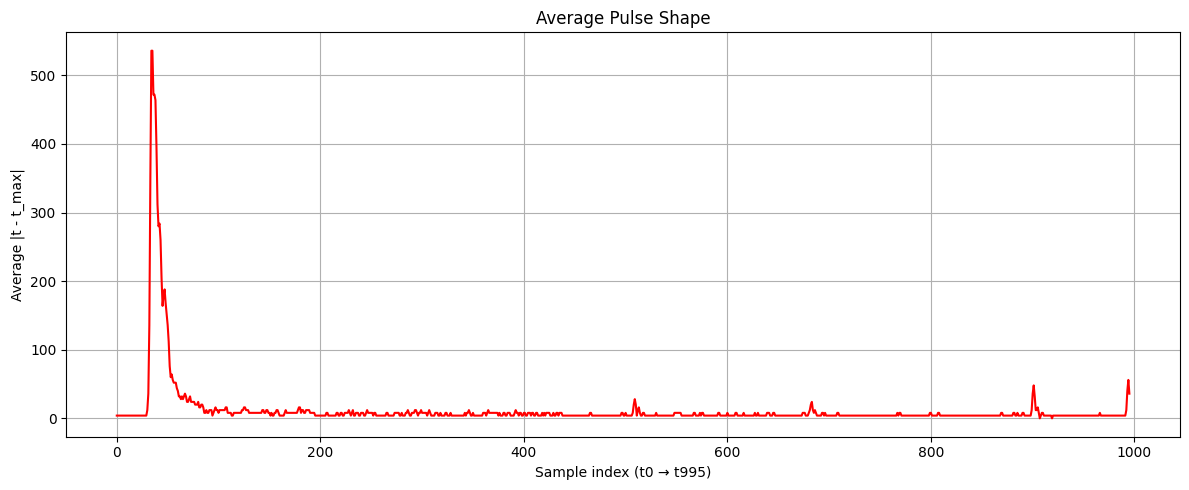

In [ ]:

# Compute column-wise mean
t_cols = [f't{i}' for i in range(996)]
df_expanded_neutron = df_expanded_neutron[t_cols]
df_expanded_gamma = df_expanded_gamma[t_cols]
neutron_row = df_expanded_neutron.loc[1533]
gamma_row = df_expanded_gamma.loc[11191]



plt.figure(figsize=(12, 5))
#plt.plot(range(len(gamma_row)), gamma_row, color='blue', linewidth=1.5)
plt.plot(range(len(neutron_row)), neutron_row, color='red', linewidth=1.5)
plt.xlabel("Sample index (t0 → t995)")
plt.ylabel("Average |t - t_max|")
plt.title("Average Pulse Shape")
plt.grid(True)
plt.tight_layout()
plt.show()
# Plot

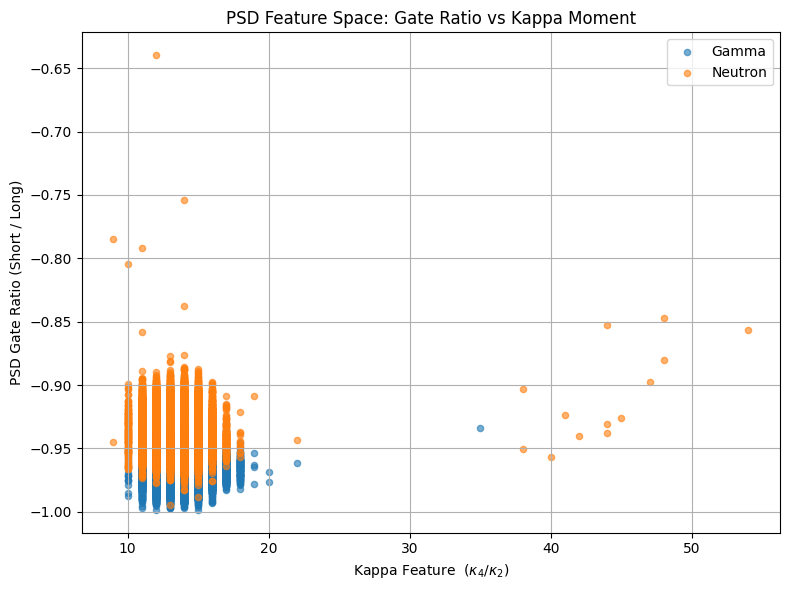

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# USER PARAMETERS
# ======================================
short_start = 25
long_end = 105
split = 55         # choose best/physical split

# ======================================
# PART 1: PSD GATE RATIO (Y-AXIS)
# ======================================



# ======================================
# PART 2: KAPPA MOMENT FEATURE (X-AXIS)
# ======================================



gamma_kappa = df_expanded_gamma["width_at_1_3"] # or use k4_gamma directly

neutron_kappa = df_expanded_neutron["width_at_1_3"]


# ======================================
# SANITY CHECK
# ======================================
assert len(gamma_ratio) == len(gamma_kappa), "Gamma size mismatch"
assert len(neutron_ratio) == len(neutron_kappa), "Neutron size mismatch"

# ======================================
# PART 3: 2D SCATTER PLOT
# ======================================

plt.figure(figsize=(8, 6))

plt.scatter(
    gamma_kappa,
    gamma_ratio,
    s=20,
    alpha=0.6,
    label="Gamma",

)

plt.scatter(
    neutron_kappa,
    neutron_ratio,
    s=20,
    alpha=0.6,
    label="Neutron"
)

plt.xlabel(r"Kappa Feature  ($\kappa_4 / \kappa_2$)")
plt.ylabel("PSD Gate Ratio (Short / Long)")
plt.title("PSD Feature Space: Gate Ratio vs Kappa Moment")
plt.legend()
plt.grid(True)

# Optional: log scaling (often improves PSD separation)
# plt.xscale("log")
# plt.yscale("log")

plt.tight_layout()
plt.show()


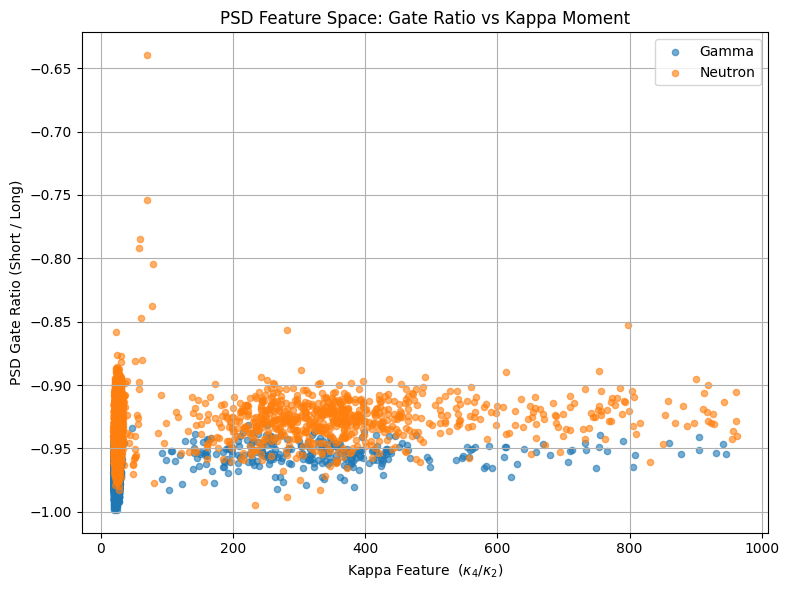

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================
# USER PARAMETERS
# ======================================
short_start = 25
long_end = 105
split = 55         # choose best/physical split

# ======================================
# PART 1: PSD GATE RATIO (Y-AXIS)
# ======================================



# ======================================
# PART 2: KAPPA MOMENT FEATURE (X-AXIS)
# ======================================



gamma_kappa = df_expanded_gamma["width_at_1_10"] # or use k4_gamma directly

neutron_kappa = df_expanded_neutron["width_at_1_10"]


# ======================================
# SANITY CHECK
# ======================================
assert len(gamma_ratio) == len(gamma_kappa), "Gamma size mismatch"
assert len(neutron_ratio) == len(neutron_kappa), "Neutron size mismatch"

# ======================================
# PART 3: 2D SCATTER PLOT
# ======================================

plt.figure(figsize=(8, 6))

plt.scatter(
    gamma_kappa,
    gamma_ratio,
    s=20,
    alpha=0.6,
    label="Gamma",

)

plt.scatter(
    neutron_kappa,
    neutron_ratio,
    s=20,
    alpha=0.6,
    label="Neutron"
)

plt.xlabel(r"Kappa Feature  ($\kappa_4 / \kappa_2$)")
plt.ylabel("PSD Gate Ratio (Short / Long)")
plt.title("PSD Feature Space: Gate Ratio vs Kappa Moment")
plt.legend()
plt.grid(True)

# Optional: log scaling (often improves PSD separation)
# plt.xscale("log")
# plt.yscale("log")

plt.tight_layout()
plt.show()
